# CCS4354 — Tensors and Graph Neural Networks
## Final Assignment — Group 05
**Students:** W.A.P.M. Weerakkody | S.S. Ellawala | Devanga Wettasinghe  
**Dataset:** OGBN-Arxiv (Open Graph Benchmark)  
**Models:** GCN · GraphSAGE · GATv2

---

## 1. Environment Setup & Installations

In [ ]:
# ── Install required packages ──────────────────────────────────────────────────
import subprocess, sys

# Step 1: Check current torch version (Colab already has torch installed)
import torch
torch_version = torch.__version__
cuda_version = torch.version.cuda
print(f"PyTorch: {torch_version}")
print(f"CUDA:    {cuda_version}")

# Step 2: Install PyG dependencies matching Colab's torch version
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-q',
    'torch-scatter',
    '-f', f'https://data.pyg.org/whl/torch-{torch_version}.html'
])

subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-q',
    'torch-sparse',
    '-f', f'https://data.pyg.org/whl/torch-{torch_version}.html'
])

subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-q',
    'torch-geometric'
])

subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-q',
    'ogb'
])

print('✓ All packages installed successfully')

PyTorch: 2.10.0+cu128
CUDA:    12.8
✓ All packages installed successfully


## 2. Imports & Device Configuration

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from torch_geometric.nn import GCNConv, SAGEConv, GATv2Conv
from torch_geometric.utils import to_networkx
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator

# ── Device ─────────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


## 3. Tensor Operations — Fundamentals

In [ ]:
print('='*60)
print('TENSOR OPERATIONS DEMONSTRATION')
print('='*60)

# --- 3.1 Tensor Creation ---
t_zeros   = torch.zeros(3, 4)
t_ones    = torch.ones(3, 4)
t_rand    = torch.rand(3, 4)
t_manual  = torch.tensor([[1., 2., 3.], [4., 5., 6.]], dtype=torch.float32)

print('\n[3.1] Tensor Creation')
print(f'  zeros(3,4):   shape={t_zeros.shape}, dtype={t_zeros.dtype}')
print(f'  rand(3,4):    min={t_rand.min():.4f}, max={t_rand.max():.4f}')
print(f'  manual:       \n{t_manual}')

# --- 3.2 Indexing & Slicing ---
print('\n[3.2] Indexing & Slicing')
print(f'  t_manual[0]:     {t_manual[0]}')
print(f'  t_manual[:, 1]:  {t_manual[:, 1]}')
print(f'  t_manual[0, 1:]: {t_manual[0, 1:]}')

# --- 3.3 Reshaping ---
print('\n[3.3] Reshaping')
t_flat  = t_manual.reshape(-1)
t_3d    = t_manual.unsqueeze(0)   # adds batch dim
t_T     = t_manual.T
print(f'  reshape(-1):     {t_flat.shape}')
print(f'  unsqueeze(0):    {t_3d.shape}')
print(f'  transpose:       {t_T.shape}')

# --- 3.4 Arithmetic ---
print('\n[3.4] Arithmetic Operations')
a = torch.tensor([[1., 2.], [3., 4.]])
b = torch.tensor([[5., 6.], [7., 8.]])
print(f'  Element-wise mul:\n{a * b}')
print(f'  Matrix mul (matmul):\n{torch.matmul(a, b)}')
print(f'  Dot product (a[0]·b[0]):  {torch.dot(a[0], b[0])}')

# --- 3.5 Aggregation ---
print('\n[3.5] Aggregation')
t_agg = torch.rand(5, 128)  # simulates 5-node feature matrix
print(f'  Feature tensor:  shape={t_agg.shape}')
print(f'  Row mean:        shape={t_agg.mean(dim=1).shape}  (per-node)')
print(f'  Col std:         shape={t_agg.std(dim=0).shape}   (per-feature)')

# --- 3.6 GPU Transfer ---
print('\n[3.6] CPU → GPU Transfer')
t_cpu = torch.randn(1000, 1000)
t_gpu = t_cpu.to(device)
print(f'  CPU tensor device: {t_cpu.device}')
print(f'  GPU tensor device: {t_gpu.device}')

start = time.time()
_ = torch.matmul(t_cpu, t_cpu)
cpu_time = time.time() - start

start = time.time()
_ = torch.matmul(t_gpu, t_gpu)
torch.cuda.synchronize() if device.type == 'cuda' else None
gpu_time = time.time() - start

print(f'  Matmul 1000×1000 — CPU: {cpu_time*1000:.2f} ms | GPU: {gpu_time*1000:.2f} ms')
print(f'  Speedup: {cpu_time/gpu_time:.1f}×')

TENSOR OPERATIONS DEMONSTRATION

[3.1] Tensor Creation
  zeros(3,4):   shape=torch.Size([3, 4]), dtype=torch.float32
  rand(3,4):    min=0.0335, max=0.8521
  manual:       
tensor([[1., 2., 3.],
        [4., 5., 6.]])

[3.2] Indexing & Slicing
  t_manual[0]:     tensor([1., 2., 3.])
  t_manual[:, 1]:  tensor([2., 5.])
  t_manual[0, 1:]: tensor([2., 3.])

[3.3] Reshaping
  reshape(-1):     torch.Size([6])
  unsqueeze(0):    torch.Size([1, 2, 3])
  transpose:       torch.Size([3, 2])

[3.4] Arithmetic Operations
  Element-wise mul:
tensor([[ 5., 12.],
        [21., 32.]])
  Matrix mul (matmul):
tensor([[19., 22.],
        [43., 50.]])
  Dot product (a[0]·b[0]):  17.0

[3.5] Aggregation
  Feature tensor:  shape=torch.Size([5, 128])
  Row mean:        shape=torch.Size([5])  (per-node)
  Col std:         shape=torch.Size([128])   (per-feature)

[3.6] CPU → GPU Transfer
  CPU tensor device: cpu
  GPU tensor device: cuda:0
  Matmul 1000×1000 — CPU: 58.77 ms | GPU: 240.02 ms
  Speedup: 0.2×


## 4. Graph Theory Fundamentals

GRAPH THEORY FUNDAMENTALS

[4.1] Karate Club Graph
  Nodes: 34
  Edges: 78
  Density: 0.1390
  Avg clustering coeff: 0.5706
  Diameter: 5

[4.2] Adjacency Matrix
  Shape: (34, 34)
  Non-zero entries: 462
  Normalised A_hat (first 5×5):
[[0.024 0.115 0.134 0.109 0.164]
 [0.115 0.034 0.194 0.131 0.   ]
 [0.134 0.194 0.03  0.123 0.   ]
 [0.109 0.131 0.123 0.056 0.   ]
 [0.164 0.    0.    0.    0.125]]


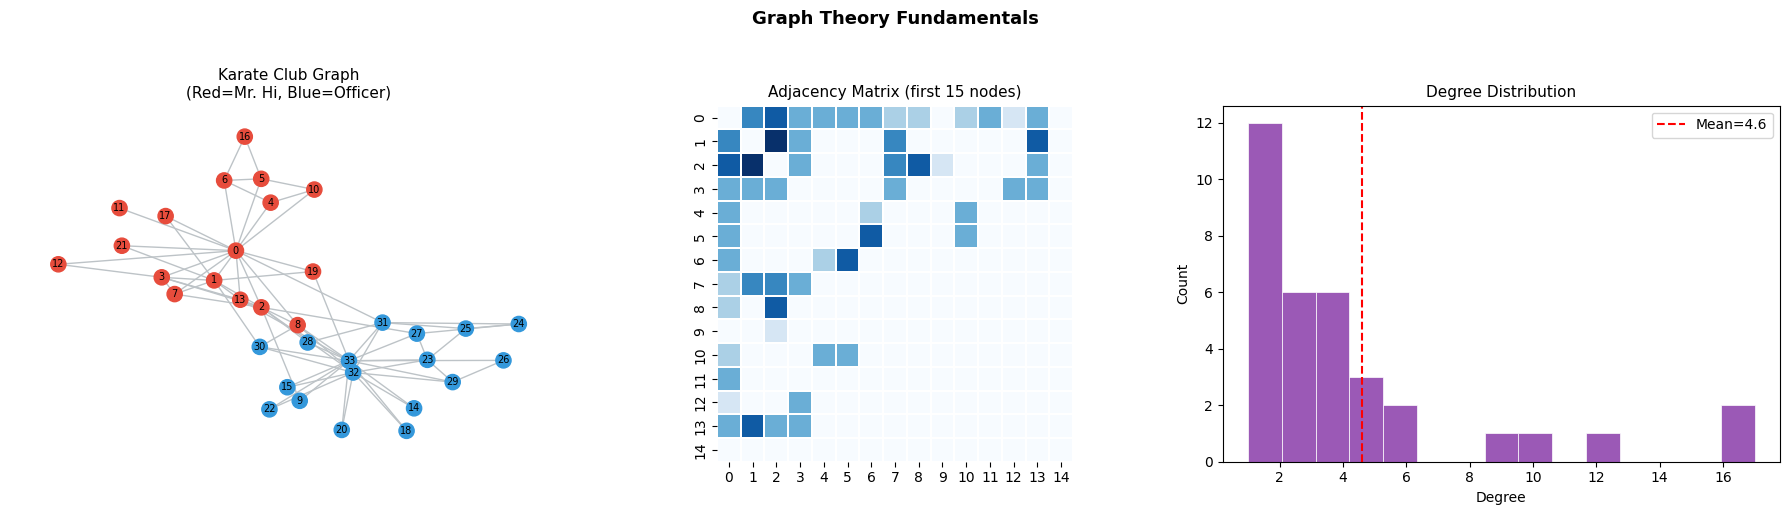


[4.4] Minimum Spanning Tree
  MST edges: 33 (= nodes-1 = 33)

[4.5] PyG edge_index Representation
  edge_index shape: torch.Size([2, 156])
  First 5 edges: [[0, 1], [0, 2], [0, 3], [0, 4], [0, 5]]


In [ ]:
print('='*60)
print('GRAPH THEORY FUNDAMENTALS')
print('='*60)

# --- 4.1 Build a sample undirected graph ---
G = nx.karate_club_graph()  # classic benchmark graph
print(f'\n[4.1] Karate Club Graph')
print(f'  Nodes: {G.number_of_nodes()}')
print(f'  Edges: {G.number_of_edges()}')
print(f'  Density: {nx.density(G):.4f}')
print(f'  Avg clustering coeff: {nx.average_clustering(G):.4f}')
print(f'  Diameter: {nx.diameter(G)}')

# --- 4.2 Adjacency matrix (sparse) ---
A = nx.adjacency_matrix(G).toarray().astype(np.float32)
D = np.diag(A.sum(axis=1))         # degree matrix
D_inv_sqrt = np.diag(1.0 / np.sqrt(A.sum(axis=1) + 1e-8))
A_hat = np.eye(len(G)) + A         # A + I (self-loops)
A_norm = D_inv_sqrt @ A_hat @ D_inv_sqrt  # symmetric normalised adj

print(f'\n[4.2] Adjacency Matrix')
print(f'  Shape: {A.shape}')
print(f'  Non-zero entries: {int(A.sum())}')
print(f'  Normalised A_hat (first 5×5):\n{np.round(A_norm[:5,:5], 3)}')

# --- 4.3 Graph visualisation ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graph
pos = nx.spring_layout(G, seed=42)
clubs = [G.nodes[n]['club'] for n in G.nodes]
color_map = ['#E74C3C' if c == 'Mr. Hi' else '#3498DB' for c in clubs]
nx.draw_networkx(G, pos, ax=axes[0], node_color=color_map,
                 node_size=120, font_size=7, edge_color='#BDC3C7',
                 with_labels=True)
axes[0].set_title('Karate Club Graph\n(Red=Mr. Hi, Blue=Officer)', fontsize=11)
axes[0].axis('off')

# Adjacency matrix heatmap
sns.heatmap(A[:15,:15], ax=axes[1], cmap='Blues', linewidths=0.3,
            linecolor='white', cbar=False, square=True)
axes[1].set_title('Adjacency Matrix (first 15 nodes)', fontsize=11)

# Degree distribution
degrees = [d for _, d in G.degree()]
axes[2].hist(degrees, bins=15, color='#9B59B6', edgecolor='white', linewidth=0.5)
axes[2].set_xlabel('Degree')
axes[2].set_ylabel('Count')
axes[2].set_title('Degree Distribution', fontsize=11)
axes[2].axvline(np.mean(degrees), color='red', linestyle='--',
                label=f'Mean={np.mean(degrees):.1f}')
axes[2].legend()

plt.suptitle('Graph Theory Fundamentals', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graph_theory_viz.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 4.4 Minimum Spanning Tree ---
mst = nx.minimum_spanning_tree(G)
print(f'\n[4.4] Minimum Spanning Tree')
print(f'  MST edges: {mst.number_of_edges()} (= nodes-1 = {G.number_of_nodes()-1})')

# --- 4.5 PyG edge_index representation ---
print('\n[4.5] PyG edge_index Representation')
edges = list(G.edges())
src = [e[0] for e in edges] + [e[1] for e in edges]  # undirected: both directions
dst = [e[1] for e in edges] + [e[0] for e in edges]
edge_index = torch.tensor([src, dst], dtype=torch.long)
print(f'  edge_index shape: {edge_index.shape}')
print(f'  First 5 edges: {edge_index[:, :5].T.tolist()}')

## 5. Dataset Loading & Preprocessing — OGBN-Arxiv

In [ ]:
print('='*60)
print('DATASET: OGBN-ARXIV')
print('='*60)

# ── Fix for PyTorch 2.6 weights_only=True breaking PyG ──────────────────────
import torch
from torch_geometric.data.data import DataEdgeAttr, DataTensorAttr
from torch_geometric.data.storage import GlobalStorage

torch.serialization.add_safe_globals([
    DataEdgeAttr,
    DataTensorAttr,
    GlobalStorage
])

# ── Load ─────────────────────────────────────────────────────────────────────
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator

dataset   = PygNodePropPredDataset(name='ogbn-arxiv', root='data/')
data      = dataset[0]
split_idx = dataset.get_idx_split()
evaluator = Evaluator(name='ogbn-arxiv')

print(f'\nDataset info:')
print(f'  Nodes:           {data.num_nodes:,}')
print(f'  Edges:           {data.num_edges:,}')
print(f'  Node features:   {data.num_node_features}')
print(f'  Classes:         {dataset.num_classes}')
print(f'  Train nodes:     {len(split_idx["train"]):,}')
print(f'  Val nodes:       {len(split_idx["valid"]):,}')
print(f'  Test nodes:      {len(split_idx["test"]):,}')

# ── Feature normalisation ────────────────────────────────────────────────────
x    = data.x.float()
mean = x[split_idx['train']].mean(dim=0, keepdim=True)
std  = x[split_idx['train']].std(dim=0,  keepdim=True) + 1e-8
x    = (x - mean) / std

data.x = x
data   = data.to(device)

train_idx = split_idx['train'].to(device)
valid_idx = split_idx['valid'].to(device)
test_idx  = split_idx['test'].to(device)

print(f'\n  Feature normalisation (z-score on train stats):')
print(f'  x mean (post-norm):  {x.mean().item():.4f}')
print(f'  x std  (post-norm):  {x.std().item():.4f}')
print(f'\n  Data moved to: {data.x.device}')

DATASET: OGBN-ARXIV

Dataset info:
  Nodes:           169,343
  Edges:           1,166,243
  Node features:   128
  Classes:         40
  Train nodes:     90,941
  Val nodes:       29,799
  Test nodes:      48,603

  Feature normalisation (z-score on train stats):
  x mean (post-norm):  -0.0036
  x std  (post-norm):  0.9924

  Data moved to: cuda:0


## 6. GNN Model Definitions

In [ ]:
# 6.1  Graph Convolutional Network (GCN)
class GCN(nn.Module):
    """3-layer GCN with BatchNorm, Dropout and residual skip."""
    def __init__(self, in_channels, hidden_channels, out_channels,
                 num_layers=3, dropout=0.5):
        super().__init__()
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()

        self.convs.append(GCNConv(in_channels, hidden_channels))
        self.bns.append(nn.BatchNorm1d(hidden_channels))
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
            self.bns.append(nn.BatchNorm1d(hidden_channels))
        self.convs.append(GCNConv(hidden_channels, out_channels))

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.convs[-1](x, edge_index)
        return x

# 6.2  GraphSAGE
class GraphSAGE(nn.Module):
    """3-layer GraphSAGE with 'mean' aggregation, BN, Dropout."""
    def __init__(self, in_channels, hidden_channels, out_channels,
                 num_layers=3, dropout=0.5):
        super().__init__()
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()

        self.convs.append(SAGEConv(in_channels, hidden_channels, aggr='mean'))
        self.bns.append(nn.BatchNorm1d(hidden_channels))
        for _ in range(num_layers - 2):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels, aggr='mean'))
            self.bns.append(nn.BatchNorm1d(hidden_channels))
        self.convs.append(SAGEConv(hidden_channels, out_channels, aggr='mean'))

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.convs[-1](x, edge_index)
        return x

# 6.3  Graph Attention Network v2 (GATv2)
class GAT(nn.Module):
    """3-layer GATv2 with 4 attention heads, BN, Dropout."""
    def __init__(self, in_channels, hidden_channels, out_channels,
                 num_layers=3, heads=4, dropout=0.5):
        super().__init__()
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()

        self.convs.append(GATv2Conv(in_channels, hidden_channels, heads=heads,
                                    concat=True, dropout=dropout))
        self.bns.append(nn.BatchNorm1d(hidden_channels * heads))
        for _ in range(num_layers - 2):
            self.convs.append(GATv2Conv(hidden_channels * heads, hidden_channels,
                                        heads=heads, concat=True, dropout=dropout))
            self.bns.append(nn.BatchNorm1d(hidden_channels * heads))
        self.convs.append(GATv2Conv(hidden_channels * heads, out_channels,
                                    heads=1, concat=False, dropout=dropout))

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.elu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.convs[-1](x, edge_index)
        return x


# ── Model summary ────────────────────────────────────────────────────────────
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

IN_CH  = data.num_node_features      # 128
HIDDEN = 256
OUT_CH = dataset.num_classes         # 40

gcn_model   = GCN(IN_CH, HIDDEN, OUT_CH).to(device)
sage_model  = GraphSAGE(IN_CH, HIDDEN, OUT_CH).to(device)
gat_model   = GAT(IN_CH, HIDDEN // 4, OUT_CH, heads=4).to(device)

print('Model Parameter Counts')
print(f'  GCN:        {count_params(gcn_model):>10,}')
print(f'  GraphSAGE:  {count_params(sage_model):>10,}')
print(f'  GATv2:      {count_params(gat_model):>10,}')

Model Parameter Counts
  GCN:           110,120
  GraphSAGE:     218,664
  GATv2:         220,320


## 7. Training Infrastructure

In [ ]:
def train(model, data, train_idx, optimizer):
    model.train()
    optimizer.zero_grad()
    out  = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[train_idx], data.y.squeeze(1)[train_idx])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    return float(loss)


@torch.no_grad()
def evaluate(model, data, split_idx, evaluator):
    model.eval()
    out  = model(data.x, data.edge_index)
    pred = out.argmax(dim=-1, keepdim=True)
    y    = data.y
    results = {}
    for split, idx in split_idx.items():
        acc = evaluator.eval({'y_true': y[idx], 'y_pred': pred[idx]})['acc']
        results[split] = acc
    return results


def run_experiment(model, model_name, epochs=200, lr=0.01, weight_decay=0.0):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr,
                                  weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=epochs, eta_min=1e-5)

    history = {'loss': [], 'val_acc': [], 'train_acc': []}
    best_val, best_test, best_epoch = 0.0, 0.0, 0
    patience, no_improve = 30, 0

    t_start = time.time()
    for epoch in range(1, epochs + 1):
        loss = train(model, data, train_idx, optimizer)
        scheduler.step()

        if epoch % 5 == 0 or epoch == 1:
            res = evaluate(model, data, split_idx, evaluator)
            history['loss'].append(loss)
            history['val_acc'].append(res['valid'])
            history['train_acc'].append(res['train'])

            if res['valid'] > best_val:
                best_val   = res['valid']
                best_test  = res['test']
                best_epoch = epoch
                no_improve = 0
                torch.save(model.state_dict(), f'best_{model_name}.pt')
            else:
                no_improve += 1

            if epoch % 25 == 0:
                print(f'  [{model_name}] Epoch {epoch:03d} | '
                      f'Loss: {loss:.4f} | '
                      f'Val: {res["valid"]*100:.2f}% | '
                      f'Test: {res["test"]*100:.2f}%')

            if no_improve >= patience:
                print(f'  Early stopping at epoch {epoch}')
                break

    elapsed = time.time() - t_start
    print(f'\n  ✓ {model_name} | Best Val: {best_val*100:.2f}% | '
          f'Best Test: {best_test*100:.2f}% | '
          f'Epoch: {best_epoch} | Time: {elapsed:.1f}s')

    return {
        'model_name': model_name,
        'best_val':   round(best_val  * 100, 2),
        'best_test':  round(best_test * 100, 2),
        'best_epoch': best_epoch,
        'train_time': round(elapsed, 1),
        'params':     count_params(model),
        'history':    history
    }

## 8. Train All Models

In [ ]:
EPOCHS = 200

print('Training GCN ...')
gcn_results  = run_experiment(gcn_model,  'GCN',       epochs=EPOCHS, lr=0.01)

print('\nTraining GraphSAGE ...')
sage_results = run_experiment(sage_model, 'GraphSAGE', epochs=EPOCHS, lr=0.01)

print('\nTraining GATv2 ...')
gat_results  = run_experiment(gat_model,  'GATv2',     epochs=EPOCHS, lr=0.005)

Training GCN ...
  [GCN] Epoch 025 | Loss: 1.5511 | Val: 57.04% | Test: 50.45%
  [GCN] Epoch 050 | Loss: 1.4394 | Val: 59.25% | Test: 52.97%
  [GCN] Epoch 075 | Loss: 1.3845 | Val: 59.91% | Test: 53.91%
  [GCN] Epoch 100 | Loss: 1.3496 | Val: 60.27% | Test: 54.19%
  [GCN] Epoch 125 | Loss: 1.3311 | Val: 60.43% | Test: 54.33%
  [GCN] Epoch 150 | Loss: 1.3130 | Val: 60.68% | Test: 54.42%
  [GCN] Epoch 175 | Loss: 1.3132 | Val: 60.65% | Test: 54.49%
  [GCN] Epoch 200 | Loss: 1.3160 | Val: 60.63% | Test: 54.43%

  ✓ GCN | Best Val: 60.68% | Best Test: 54.42% | Epoch: 150 | Time: 47.6s

Training GraphSAGE ...
  [GraphSAGE] Epoch 025 | Loss: 1.4238 | Val: 58.68% | Test: 52.02%
  [GraphSAGE] Epoch 050 | Loss: 1.2820 | Val: 61.35% | Test: 54.98%
  [GraphSAGE] Epoch 075 | Loss: 1.2092 | Val: 62.24% | Test: 55.97%
  [GraphSAGE] Epoch 100 | Loss: 1.1576 | Val: 62.96% | Test: 56.24%
  [GraphSAGE] Epoch 125 | Loss: 1.1269 | Val: 63.20% | Test: 56.46%
  [GraphSAGE] Epoch 150 | Loss: 1.1090 | Val: 63

## 9. Results Visualisation

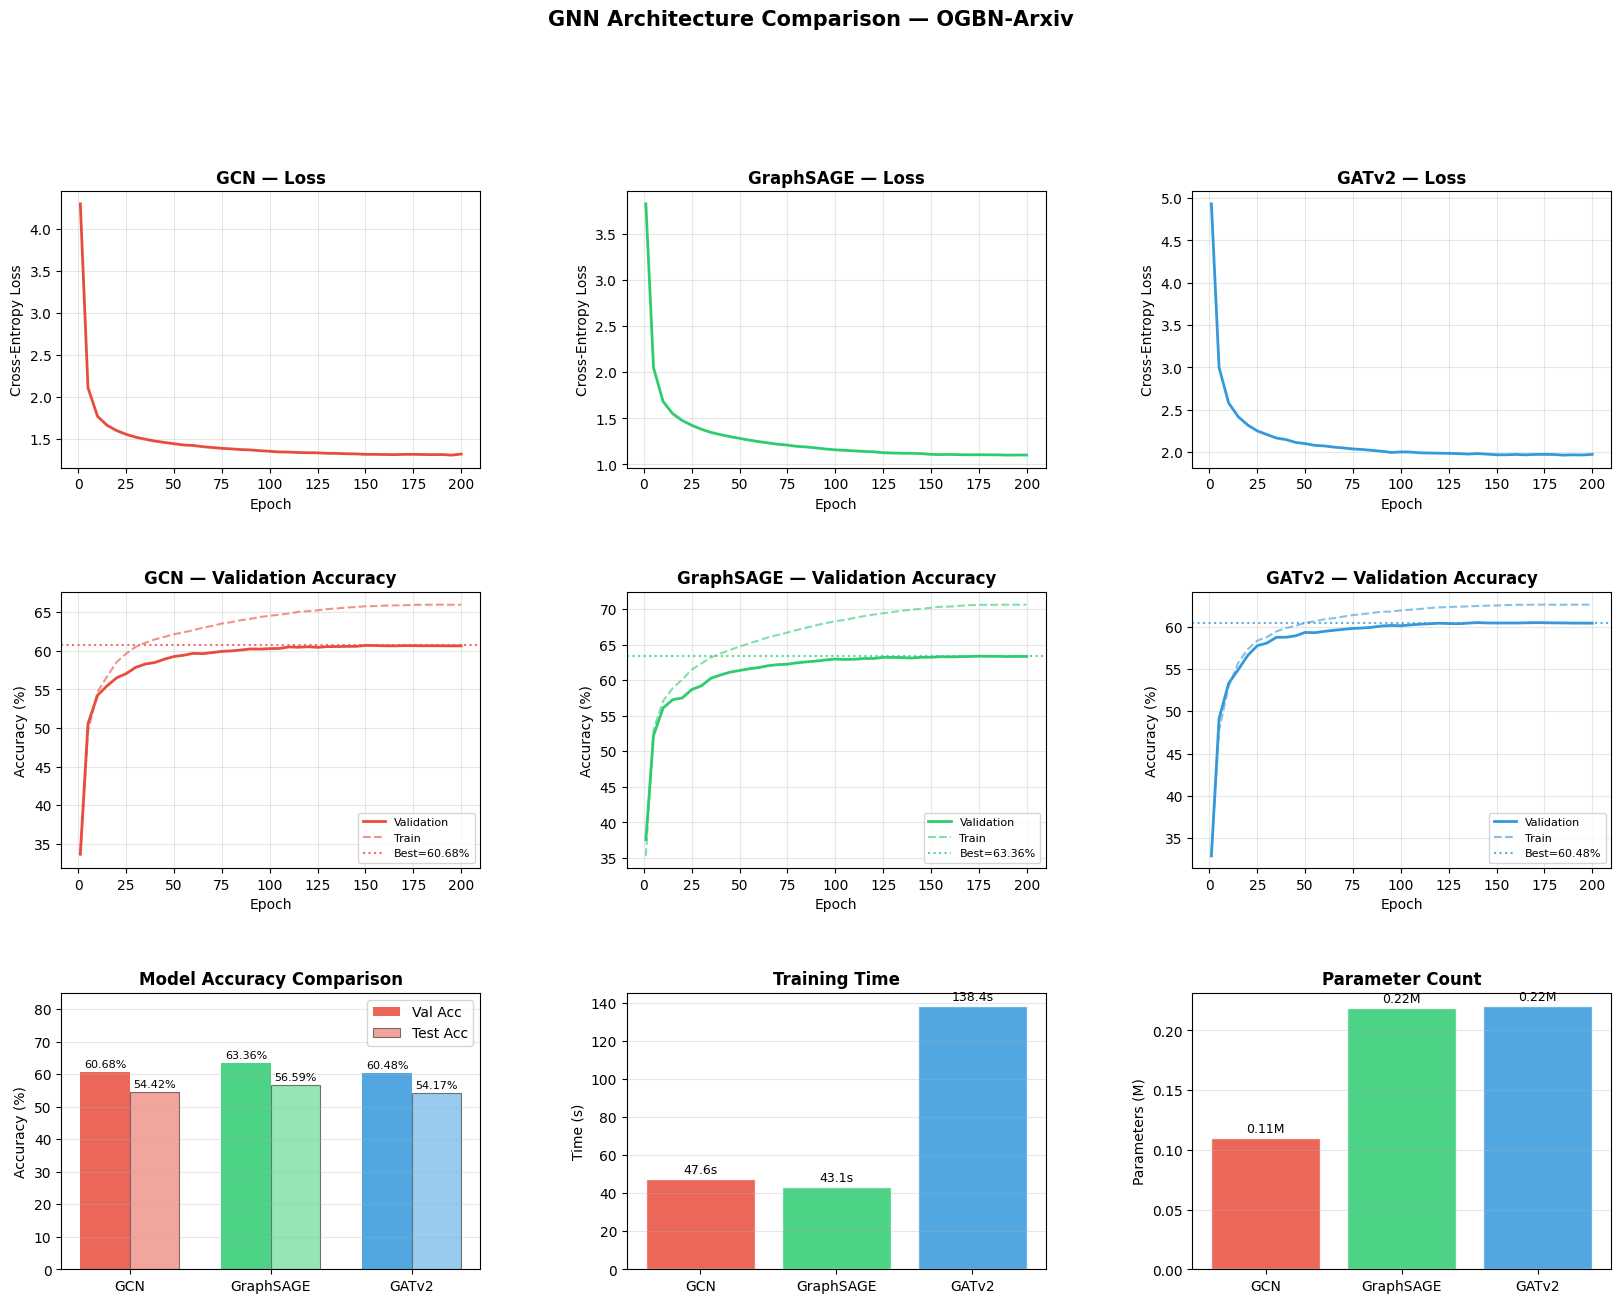


Model             Val Acc   Test Acc     Params     Time
-----------------------------------------------------------------
GCN                60.68%     54.42%      0.11M    47.6s
GraphSAGE          63.36%     56.59%      0.22M    43.1s
GATv2              60.48%     54.17%      0.22M   138.4s


In [ ]:
all_results = [gcn_results, sage_results, gat_results]
colors      = ['#E74C3C', '#2ECC71', '#3498DB']

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Row 1: Loss curves ────────────────────────────────────────────────────────
for i, (res, col) in enumerate(zip(all_results, colors)):
    ax = fig.add_subplot(gs[0, i])
    epochs_logged = [j*5 if j > 0 else 1 for j in range(len(res['history']['loss']))]
    ax.plot(epochs_logged, res['history']['loss'], color=col, linewidth=2)
    ax.set_title(f"{res['model_name']} — Loss", fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-Entropy Loss')
    ax.grid(alpha=0.3)

# ── Row 2: Validation accuracy curves ────────────────────────────────────────
for i, (res, col) in enumerate(zip(all_results, colors)):
    ax = fig.add_subplot(gs[1, i])
    epochs_logged = [j*5 if j > 0 else 1 for j in range(len(res['history']['val_acc']))]
    ax.plot(epochs_logged, [v*100 for v in res['history']['val_acc']],
            color=col, linewidth=2, label='Validation')
    ax.plot(epochs_logged, [v*100 for v in res['history']['train_acc']],
            color=col, linewidth=1.5, linestyle='--', alpha=0.6, label='Train')
    ax.axhline(res['best_val'], color=col, linestyle=':', alpha=0.8,
               label=f'Best={res["best_val"]}%')
    ax.set_title(f"{res['model_name']} — Validation Accuracy", fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Row 3: Summary bar charts ─────────────────────────────────────────────────
names    = [r['model_name'] for r in all_results]
val_accs = [r['best_val']   for r in all_results]
tst_accs = [r['best_test']  for r in all_results]

# Accuracy comparison
ax3 = fig.add_subplot(gs[2, 0])
x   = np.arange(len(names))
w   = 0.35
bars1 = ax3.bar(x - w/2, val_accs, w, label='Val Acc', color=colors, alpha=0.85)
bars2 = ax3.bar(x + w/2, tst_accs, w, label='Test Acc', color=colors, alpha=0.5,
                edgecolor='black', linewidth=0.8)
ax3.bar_label(bars1, fmt='%.2f%%', fontsize=8, padding=2)
ax3.bar_label(bars2, fmt='%.2f%%', fontsize=8, padding=2)
ax3.set_xticks(x); ax3.set_xticklabels(names)
ax3.set_ylabel('Accuracy (%)'); ax3.set_title('Model Accuracy Comparison', fontweight='bold')
ax3.legend(); ax3.set_ylim(0, 85); ax3.grid(axis='y', alpha=0.3)

# Training time
ax4   = fig.add_subplot(gs[2, 1])
times = [r['train_time'] for r in all_results]
bars3 = ax4.bar(names, times, color=colors, alpha=0.85, edgecolor='white')
ax4.bar_label(bars3, fmt='%.1fs', fontsize=9, padding=2)
ax4.set_ylabel('Time (s)'); ax4.set_title('Training Time', fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

# Parameter count
ax5    = fig.add_subplot(gs[2, 2])
params = [r['params']/1e6 for r in all_results]
bars4  = ax5.bar(names, params, color=colors, alpha=0.85, edgecolor='white')
ax5.bar_label(bars4, fmt='%.2fM', fontsize=9, padding=2)
ax5.set_ylabel('Parameters (M)'); ax5.set_title('Parameter Count', fontweight='bold')
ax5.grid(axis='y', alpha=0.3)

plt.suptitle('GNN Architecture Comparison — OGBN-Arxiv', fontsize=15,
             fontweight='bold', y=1.01)
plt.savefig('gnn_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Numeric summary ────────────────────────────────────────────────────────────
print('\n' + '='*65)
print(f'{"Model":<14} {"Val Acc":>10} {"Test Acc":>10} {"Params":>10} {"Time":>8}')
print('-'*65)
for r in all_results:
    print(f'{r["model_name"]:<14} {r["best_val"]:>9.2f}% '
          f'{r["best_test"]:>9.2f}% '
          f'{r["params"]/1e6:>9.2f}M '
          f'{r["train_time"]:>7.1f}s')
print('='*65)

## 10. Hyperparameter Study — Hidden Dimension Effect

Hyperparameter Study: Hidden Dimension on GraphSAGE

  Hidden dim = 64
  [SAGE-64] Epoch 025 | Loss: 1.7931 | Val: 56.08% | Test: 49.82%
  [SAGE-64] Epoch 050 | Loss: 1.6340 | Val: 58.32% | Test: 52.46%
  [SAGE-64] Epoch 075 | Loss: 1.5905 | Val: 58.82% | Test: 52.66%
  [SAGE-64] Epoch 100 | Loss: 1.5841 | Val: 58.87% | Test: 52.68%

  ✓ SAGE-64 | Best Val: 58.89% | Best Test: 52.67% | Epoch: 80 | Time: 7.8s

  Hidden dim = 128
  [SAGE-128] Epoch 025 | Loss: 1.5553 | Val: 57.69% | Test: 50.95%
  [SAGE-128] Epoch 050 | Loss: 1.4286 | Val: 60.21% | Test: 53.77%
  [SAGE-128] Epoch 075 | Loss: 1.3887 | Val: 60.60% | Test: 54.26%
  [SAGE-128] Epoch 100 | Loss: 1.3800 | Val: 60.67% | Test: 54.30%

  ✓ SAGE-128 | Best Val: 60.67% | Best Test: 54.30% | Epoch: 100 | Time: 11.7s

  Hidden dim = 256
  [SAGE-256] Epoch 025 | Loss: 1.4253 | Val: 58.67% | Test: 52.04%
  [SAGE-256] Epoch 050 | Loss: 1.2959 | Val: 61.17% | Test: 54.72%
  [SAGE-256] Epoch 075 | Loss: 1.2514 | Val: 61.75% | Test: 55.21%

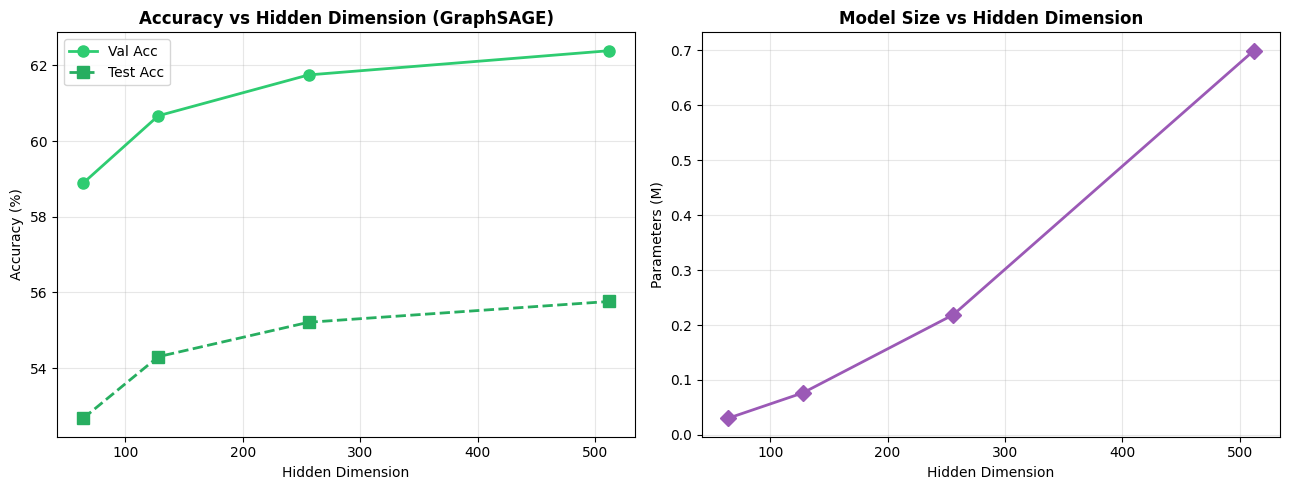

In [ ]:
print('Hyperparameter Study: Hidden Dimension on GraphSAGE')
hidden_dims = [64, 128, 256, 512]
hp_results  = []

for hd in hidden_dims:
    print(f'\n  Hidden dim = {hd}')
    m = GraphSAGE(IN_CH, hd, OUT_CH).to(device)
    r = run_experiment(m, f'SAGE-{hd}', epochs=100, lr=0.01)
    hp_results.append({'hidden': hd, 'val': r['best_val'],
                       'test': r['best_test'], 'params': r['params']})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot([r['hidden'] for r in hp_results],
             [r['val']    for r in hp_results], 'o-', color='#2ECC71', linewidth=2,
             markersize=8, label='Val Acc')
axes[0].plot([r['hidden'] for r in hp_results],
             [r['test']   for r in hp_results], 's--', color='#27AE60', linewidth=2,
             markersize=8, label='Test Acc')
axes[0].set_xlabel('Hidden Dimension'); axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Accuracy vs Hidden Dimension (GraphSAGE)', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot([r['hidden'] for r in hp_results],
             [r['params']/1e6 for r in hp_results], 'D-', color='#9B59B6',
             linewidth=2, markersize=8)
axes[1].set_xlabel('Hidden Dimension'); axes[1].set_ylabel('Parameters (M)')
axes[1].set_title('Model Size vs Hidden Dimension', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('hyperparam_study.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Final Summary

In [ ]:
best = max(all_results, key=lambda r: r['best_test'])
print('===========================================================')
print('===============FINAL EXPERIMENT SUMMARY ===================')
print('===========================================================')
print(f'  Dataset      : OGBN-Arxiv (169,343 nodes, 128 feats)  ')
print(f'  Task         : Node Classification (40 classes)        ')
print(f'  Best Model   : {best["model_name"]:<41} ')
print(f'  Best Val Acc : {best["best_val"]:<41.2f} ')
print(f' Best Test Acc: {best["best_test"]:<41.2f} ')
for r in all_results:
    print(f'║  {r["model_name"]:<10}: Val={r["best_val"]:5.2f}%  '
          f'Test={r["best_test"]:5.2f}%  '
          f'Params={r["params"]/1e6:.2f}M  ║')

===============FINAL EXPERIMENT SUMMARY ===================
  Dataset      : OGBN-Arxiv (169,343 nodes, 128 feats)  
  Task         : Node Classification (40 classes)        
  Best Model   : GraphSAGE                                 
  Best Val Acc : 63.36                                     
 Best Test Acc: 56.59                                     
║  GCN       : Val=60.68%  Test=54.42%  Params=0.11M  ║
║  GraphSAGE : Val=63.36%  Test=56.59%  Params=0.22M  ║
║  GATv2     : Val=60.48%  Test=54.17%  Params=0.22M  ║
